# Lab 8

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Questions

#### 1. A: Classification of fruits
##### You are provided with a dataset of fruits. Each fruit is characterized by two features: weight (in grams) and sweetness level (on a scale of 1 to 10). You want to classify a new fruit as either an "Apple" or an "Orange" based on these features using the KNN algorithm.

Tasks: 
- Implement the KNN algorithm manually with k=3 to classify a new fruit with a weight of 165 grams and sweetness level of 5.5.
- Calculate the Euclidean, Manhattan, and  Minkowski distances between the new fruit and all the existing fruits in the dataset. Finally compare the calculated distances.
- Based on the k-nearest neighbors, determine the label for the new fruit.
- What is the effect of choosing different values of k (e.g., k=1, k=5) on the classification result?
- Implement the above using function python program without using scikit learn library.
- Plot the given samples, the Apple in Red color and the Orange in orange color. Also draw the decision boundary.

In [29]:
data = {
    "weight": [150, 180, 130, 170, 160, 140],
    "sweetness": [7, 4, 8, 5, 6, 3],
    "label": ["Apple", "Orange", "Apple", "Orange", "Apple", "Orange"]
}

df = pd.DataFrame(data)
df.to_csv("fruits.csv", index=False)

In [30]:
df = pd.read_csv("fruits.csv")
df.head()

,weight,sweetness,label
0,150,7,Apple
1,180,4,Orange
2,130,8,Apple
3,170,5,Orange
4,160,6,Apple


In [31]:
new_weight = 165
new_sweetness = 5.5

new_fruit = np.array([new_weight, new_sweetness])

In [32]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [33]:
euclidean_distances = []
manhattan_distances = []
minkowski_distances = []

for i in range(len(df)):
    fruit = np.array([
        df.loc[i, "weight"],
        df.loc[i, "sweetness"]
    ])

    euclidean_distances.append(euclidean_distance(new_fruit, fruit))
    manhattan_distances.append(manhattan_distance(new_fruit, fruit))
    minkowski_distances.append(minkowski_distance(new_fruit, fruit, p=3))

df["euclidean"] = euclidean_distances
df["manhattan"] = manhattan_distances
df["minkowski"] = minkowski_distances

df.head()

,weight,sweetness,label,euclidean,manhattan,minkowski
0,150,7,Apple,15.074813,16.5,15.004998
1,180,4,Orange,15.074813,16.5,15.004998
2,130,8,Apple,35.089172,37.5,35.004251
3,170,5,Orange,5.024938,5.5,5.001666
4,160,6,Apple,5.024938,5.5,5.001666


In [34]:
from collections import Counter

def knn_predict(df, new_point, k=3, metric="euclidean", p=3):
    distances = []

    for i in range(len(df)):
        point = np.array([
            df.loc[i, "weight"],
            df.loc[i, "sweetness"]
        ])

        if metric == "euclidean":
            distance = euclidean_distance(new_point, point)

        elif metric == "manhattan":
            distance = manhattan_distance(new_point, point)

        elif metric == "minkowski":
            distance = minkowski_distance(new_point, point)

        else:
            raise ValueError("Invalid distance metric.")

        distances.append((distance, df.loc[i, "label"]))

    distances.sort(key=lambda x: x[0])
    nearest_neighbors = distances[:k]
    labels = [neighbor[1] for neighbor in nearest_neighbors]
    prediction = Counter(labels).most_common(1)[0][0]

    return prediction, nearest_neighbors

In [35]:
K = 3
prediction, neighbors = knn_predict(df, new_fruit, k=K)

print(f"{K} nearest neighbors:")
for distance, label in neighbors:
    print(f"Distance = {distance:.3f}, Label = {label}")

print(f"\nPredicted class: {prediction}")

3 nearest neighbors:
Distance = 5.025, Label = Orange
Distance = 5.025, Label = Apple
Distance = 15.075, Label = Apple

Predicted class: Apple


In [36]:
for k in [1, 3, 5]:
    prediction, neighbors = knn_predict(df, new_fruit, k=k)

    print(f"k = {k}")
    print(f"Neighbors:")
    for distance, label in neighbors:
        print(f"Distance = {distance:.3f}, Label = {label}")

    print(f"\nPredicted class: {prediction}")
    print("\n")

k = 1
Neighbors:
Distance = 5.025, Label = Orange

Predicted class: Orange


k = 3
Neighbors:
Distance = 5.025, Label = Orange
Distance = 5.025, Label = Apple
Distance = 15.075, Label = Apple

Predicted class: Apple


k = 5
Neighbors:
Distance = 5.025, Label = Orange
Distance = 5.025, Label = Apple
Distance = 15.075, Label = Apple
Distance = 15.075, Label = Orange
Distance = 25.125, Label = Orange

Predicted class: Orange




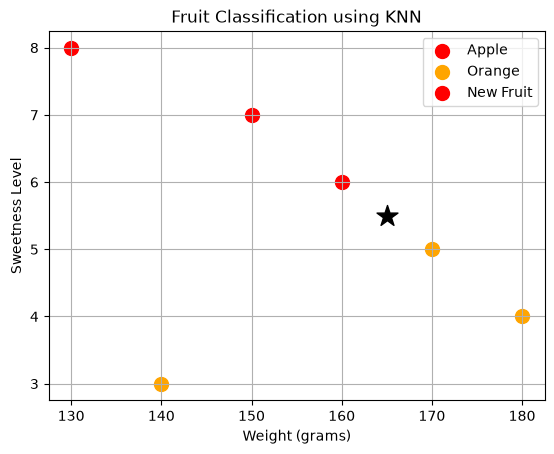

In [37]:
for i in range(len(df)):
    if df.loc[i, "label"] == "Apple":
        plt.scatter(
            df.loc[i, "weight"],
            df.loc[i, "sweetness"],
            color="red",
            s=100,
        )

    else:
        plt.scatter(
            df.loc[i, "weight"],
            df.loc[i, "sweetness"],
            color="orange",
            s=100,
        )

plt.scatter(
    new_weight,
    new_sweetness,
    color="black",
    marker="*",
    s=250,
    label="New Fruit"
)

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("Fruit Classification using KNN")

plt.legend(["Apple", "Orange", "New Fruit"])

plt.grid()
plt.show()

In [38]:
weight_min = df["weight"].min() - 10
weight_max = df["weight"].max() + 10

sweet_min = df["sweetness"].min() - 1
sweet_max = df["sweetness"].max() + 1

weight_values = np.linspace(weight_min, weight_max, 200)
sweet_values = np.linspace(sweet_min, sweet_max, 200)

W, S = np.meshgrid(weight_values, sweet_values)
Z = np.zeros(W.shape)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        point = np.array([
            W[i, j],
            S[i, j]
        ])

        prediction, _ = knn_predict(df, point, k=3)

        if prediction == "Apple":
            Z[i, j] = 0

        else:
            Z[i, j] = 1

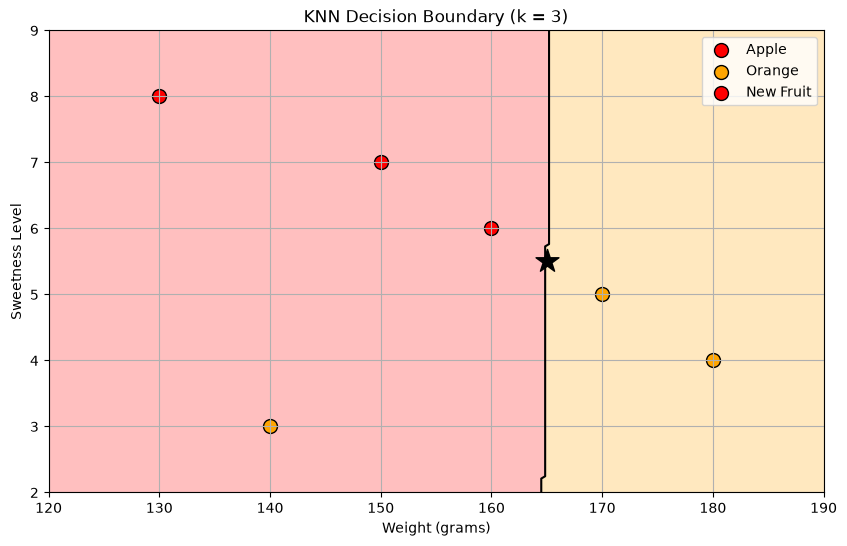

In [39]:
plt.figure(figsize=(10, 6))

plt.contourf(
    W,
    S,
    Z,
    alpha=0.25,
    levels=[-0.5, 0.5, 1.5],
    colors=["red", "orange"]
)

plt.contour(
    W,
    S,
    Z,
    levels=[0.5],
    colors="black"
)

for i in range(len(df)):
    if df.loc[i, "label"] == "Apple":
        plt.scatter(
            df.loc[i, "weight"],
            df.loc[i, "sweetness"],
            color="red",
            edgecolor="black",
            s=100
        )

    else:
        plt.scatter(
            df.loc[i, "weight"],
            df.loc[i, "sweetness"],
            color="orange",
            edgecolor="black",
            s=100
        )

plt.scatter(
    new_weight,
    new_sweetness,
    color="black",
    marker="*",
    s=300,
    label="New Fruit"
)

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("KNN Decision Boundary (k = 3)")

plt.legend(["Apple", "Orange", "New Fruit"])
plt.grid()
plt.show()

#### 1. B: Classification of fruits
##### Implement the Python code for Question 1. A using the ```scikit-learn``` library. Plot the given samples, using red for "Apple" and orange for "Orange." Also, plot the decision boundary. Calculate the distances using Euclidean, Manhattan, and Minkowski metrics, and compare the results.

In [40]:
df = pd.read_csv("fruits.csv")
df.head()

,weight,sweetness,label
0,150,7,Apple
1,180,4,Orange
2,130,8,Apple
3,170,5,Orange
4,160,6,Apple


In [41]:
X = df[["weight", "sweetness"]].values
y = df["label"].values

new_weight = 165
new_sweetness = 5.5

new_fruit = np.array([[new_weight, new_sweetness]])

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn_euclidean = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn_euclidean.fit(X, y)
prediction_euclidean = knn_euclidean.predict(new_fruit)

print(f"Prediction using Euclidean distance: {prediction_euclidean[0]}")

Prediction using Euclidean distance: Orange


In [43]:
distances, indices = knn_euclidean.kneighbors(
    new_fruit,
    n_neighbors=len(X)
)

print("Euclidean distances:")
for distance, i in zip(distances[0], indices[0]):
    print(
        f"Fruit: {i + 1}, "
        f"Distance = {distance:.4f}, "
        f"Label: {y[i]}"
    )

Euclidean distances:
Fruit: 4, Distance = 5.0249, Label: Orange
Fruit: 5, Distance = 5.0249, Label: Apple
Fruit: 2, Distance = 15.0748, Label: Orange
Fruit: 1, Distance = 15.0748, Label: Apple
Fruit: 6, Distance = 25.1247, Label: Orange
Fruit: 3, Distance = 35.0892, Label: Apple


In [44]:
knn_manhattan = KNeighborsClassifier(
    n_neighbors=3,
    metric="manhattan"
)

knn_manhattan.fit(X, y)
prediction_manhattan = knn_manhattan.predict(new_fruit)

print(f"Prediction using Manhattan distance: {prediction_manhattan[0]}")

Prediction using Manhattan distance: Orange


In [45]:
distances, indices = knn_manhattan.kneighbors(
    new_fruit,
    n_neighbors=len(X)
)

print("Manhattan distances:")
for distance, i in zip(distances[0], indices[0]):
    print(
        f"Fruit: {i + 1}, "
        f"Distance = {distance:.4f}, "
        f"Label: {y[i]}"
    )

Manhattan distances:
Fruit: 4, Distance = 5.5000, Label: Orange
Fruit: 5, Distance = 5.5000, Label: Apple
Fruit: 2, Distance = 16.5000, Label: Orange
Fruit: 1, Distance = 16.5000, Label: Apple
Fruit: 6, Distance = 27.5000, Label: Orange
Fruit: 3, Distance = 37.5000, Label: Apple


In [46]:
knn_minkowski = KNeighborsClassifier(
    n_neighbors=3,
    metric="minkowski",
    p=3
)

knn_minkowski.fit(X, y)
prediction_minkowski = knn_minkowski.predict(new_fruit)

print(f"Prediction using Minkowski distance (p = 3): {prediction_minkowski[0]}")

Prediction using Minkowski distance (p = 3): Orange


In [47]:
distances, indices = knn_minkowski.kneighbors(
    new_fruit,
    n_neighbors=len(X)
)

print("Minkowski distances (p = 3):")
for distance, i in zip(distances[0], indices[0]):
    print(
        f"Fruit: {i + 1}, "
        f"Distance = {distance:.4f}, "
        f"Label: {y[i]}"
    )

Minkowski distances (p = 3):
Fruit: 4, Distance = 5.0017, Label: Orange
Fruit: 5, Distance = 5.0017, Label: Apple
Fruit: 2, Distance = 15.0050, Label: Orange
Fruit: 1, Distance = 15.0050, Label: Apple
Fruit: 6, Distance = 25.0083, Label: Orange
Fruit: 3, Distance = 35.0043, Label: Apple


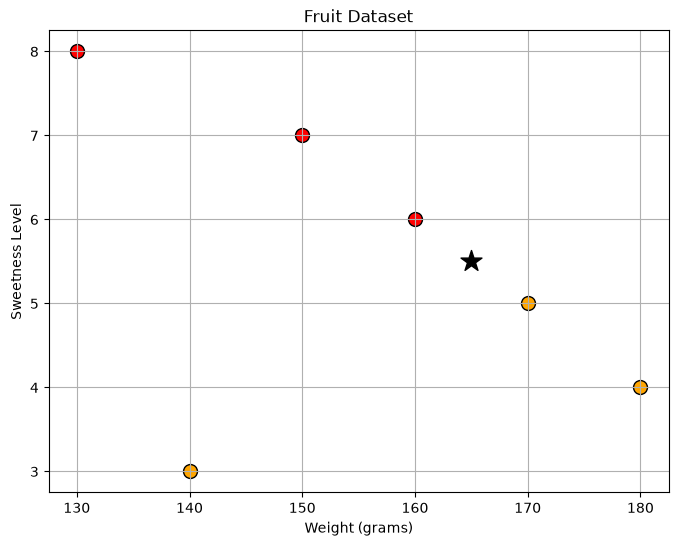

In [48]:
plt.figure(figsize=(8, 6))

for i in range(len(X)):
    if y[i] == "Apple":
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color="red",
            edgecolor="black",
            s=100
        )

    else:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color="orange",
            edgecolor="black",
            s=100
        )

plt.scatter(
    new_fruit[0, 0],
    new_fruit[0, 1],
    color="black",
    marker="*",
    s=250
)

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("Fruit Dataset")

plt.grid()
plt.show()

In [49]:
def plot_decision_boundary(model, title):
    weight_min = X[:, 0].min() - 10
    weight_max = X[:, 0].max() + 10

    sweetness_min = X[:, 1].min() - 1
    sweetness_max = X[:, 1].max() + 1

    weight_range = np.linspace(
        weight_min,
        weight_max,
        300
    )

    sweetness_range = np.linspace(
        sweetness_min,
        sweetness_max,
        300
    )

    xx, yy = np.meshgrid(
        weight_range,
        sweetness_range
    )

    grid_points = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(grid_points)

    Z = np.where(predictions == "Apple", 0, 1)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        colors=["red", "orange"],
        alpha=0.2
    )

    plt.contour(
        xx,
        yy,
        Z,
        levels=[0.5],
        colors="black"
    )

    for i in range(len(X)):
        if y[i] == "Apple":
            plt.scatter(
                X[i, 0],
                X[i, 1],
                color="red",
                edgecolor="black",
                s=100
            )

        else:
            plt.scatter(
                X[i, 0],
                X[i, 1],
                color="orange",
                edgecolor="black",
                s=100
            )

    plt.scatter(
        new_fruit[0, 0],
        new_fruit[0, 1],
        color="black",
        marker="*",
        s=250,
        label="New Fruit"
    )

    plt.xlabel("Weight (grams)")
    plt.ylabel("Sweetness Level")
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()

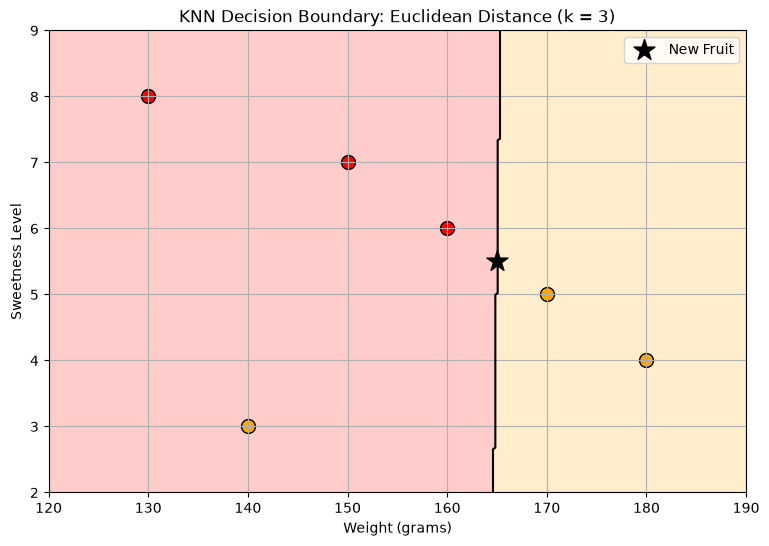

In [50]:
plot_decision_boundary(knn_euclidean, "KNN Decision Boundary: Euclidean Distance (k = 3)")

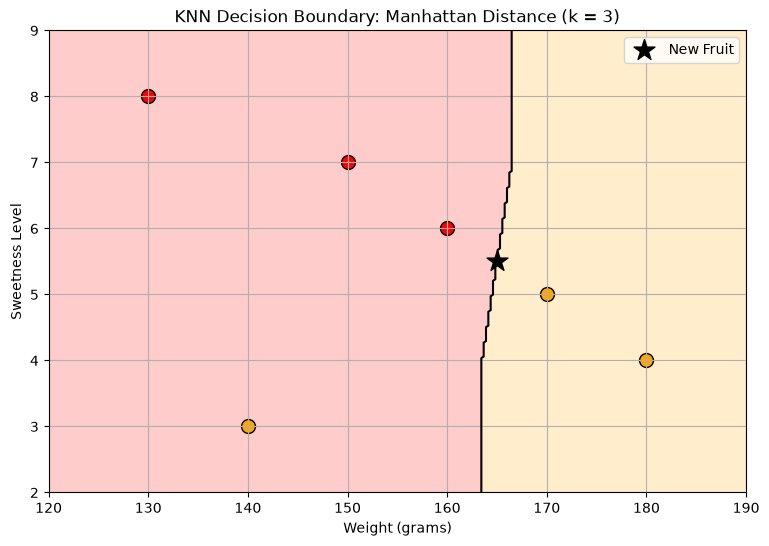

In [51]:
plot_decision_boundary(knn_manhattan, "KNN Decision Boundary: Manhattan Distance (k = 3)")

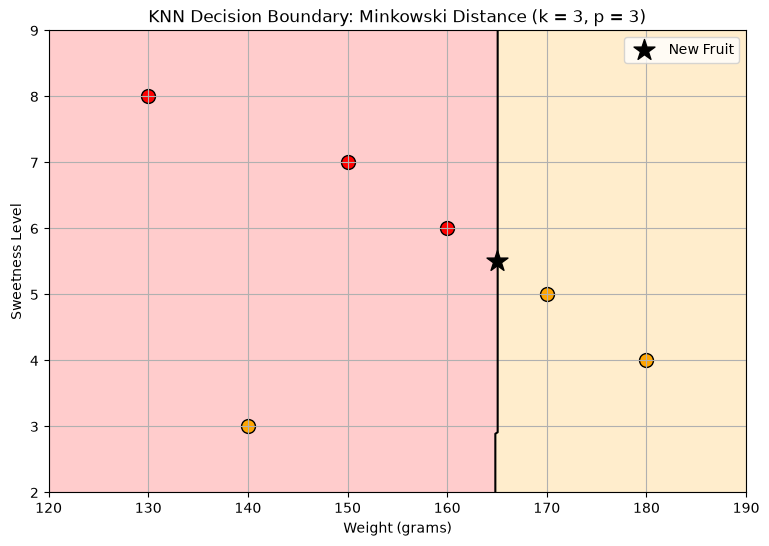

In [52]:
plot_decision_boundary(knn_minkowski, "KNN Decision Boundary: Minkowski Distance (k = 3, p = 3)")

#### 2. A: Medical diagnosis decision
##### A dataset is provided to classify patients as "Healthy" or "Sick" based on their Age, Blood Pressure, and Cholesterol levels.

Tasks:
- Calculate the entropy for the target variable (Diagnosis).
- Calculate the information gain for each feature (Age, Blood Pressure, Cholesterol).
- Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision tree.
- Build the decision tree and explain the first few splits.
- Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy or sick using the tree you built.
- Implement the above using function python program without using scikit learn library.

In [53]:
data = {
    "age": [30, 45, 50, 35, 60, 55, 40, 25, 65, 45],
    "bp": [
        "High", "Low", "High", "Low", "High",
        "Low", "High", "Low", "High", "Low"
    ],
    "cholesterol": [
        "High", "Normal", "High", "Normal", "High",
        "Normal", "High", "Normal", "High", "Normal"
    ],
    "diagnosis": [
        "Sick", "Healthy", "Sick", "Healthy", "Sick",
        "Healthy", "Sick", "Healthy", "Sick", "Healthy"
    ]
}

df = pd.DataFrame(data)
df.to_csv("diagnosis.csv", index=False)

In [54]:
df = pd.read_csv("diagnosis.csv")
df.head()

,age,bp,cholesterol,diagnosis
0,30,High,High,Sick
1,45,Low,Normal,Healthy
2,50,High,High,Sick
3,35,Low,Normal,Healthy
4,60,High,High,Sick


In [55]:
from math import log2

def entropy(labels):
    counts = labels.value_counts()
    total = len(labels)

    ent = 0

    for count in counts:
        probability = count / total
        ent -= probability * log2(probability)

    return ent

In [56]:
target_entropy = entropy(df["diagnosis"])
print(f"Entropy of diagnosis = {target_entropy}")

Entropy of diagnosis = 1.0


In [57]:
def information_gain_categorical(df, feature, target="diagnosis"):
    total_entropy = entropy(df[target])
    weighted_entropy = 0

    for value in df[feature].unique():
        subset = df[df[feature] == value]
        weight = len(subset) / len(df)
        subset_entropy = entropy(subset[target])
        weighted_entropy += weight * subset_entropy

    gain = total_entropy - weighted_entropy
    return gain

In [58]:
def information_gain_numerical(df, feature, target="diagnosis"):
    values = sorted(df[feature].unique())
    thresholds = []

    for i in range(len(values) - 1):
        threshold = (values[i] + values[i + 1]) / 2
        thresholds.append(threshold)

    total_entropy = entropy(df[target])

    best_gain = -1
    best_threshold = None

    results = []

    for threshold in thresholds:
        left = df[df[feature] <= threshold]
        right = df[df[feature] >= threshold]

        left_weight = len(left) / len(df)
        right_weight = len(right) / len(df)

        weighted_entropy = (
            left_weight * entropy(left[target])
            +
            right_weight * entropy(right[target])
        )

        gain = total_entropy - weighted_entropy

        results.append((threshold, gain))

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_gain, best_threshold, results

In [59]:
ig_bp = information_gain_categorical(df, "bp")
ig_cholesterol = information_gain_categorical(df, "cholesterol")
print(f"Information Gain (Blood Pressure): {ig_bp}")
print(f"Information Gain (Cholesterol): {ig_cholesterol}")

Information Gain (Blood Pressure): 1.0
Information Gain (Cholesterol): 1.0


In [60]:
ig_age, best_threshold, age_results = information_gain_numerical(df, "age")
print(f"Information Gain (Age): {ig_age}")
print(f"Best threshold: {best_threshold}")

Information Gain (Age): 0.2364527976600279
Best threshold: 57.5


In [61]:
for threshold, gain in age_results:
    print(
        f"Threshold: {threshold}, "
        f"Gain: {gain}"
    )

Threshold: 27.5, Gain: 0.10803154614559995
Threshold: 32.5, Gain: 0.0
Threshold: 37.5, Gain: 0.034851554559677034
Threshold: 42.5, Gain: 0.0
Threshold: 47.5, Gain: 0.12451124978365313
Threshold: 52.5, Gain: 0.034851554559677034
Threshold: 57.5, Gain: 0.2364527976600279
Threshold: 62.5, Gain: 0.10803154614559995


In [62]:
def majority_class(labels):
    return labels.value_counts().idxmax()

In [63]:
def id3(df, features, target="diagnosis"):
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    if len(features) == 0:
        return majority_class(df[target])

    gains = {}

    for feature in features:
        if pd.api.types.is_numeric_dtype(df[feature]):
            gain, threshold, _ = information_gain_numerical(df, feature, target=target)
            gains[feature] = gain, threshold
            

        else:
            gains[feature] = (
                information_gain_categorical(df, feature, target=target),
                None
            )

    best_feature = max(gains, key=lambda x: gains[x][0])
    best_gain, threshold = gains[best_feature]

    tree = {}

    if threshold is not None:
        tree[best_feature] = {
            "threshold": threshold
        }

        left = df[df[best_feature] <= threshold]
        right = df[df[best_feature] > threshold]

        remaining_features = [
            f for f in features
            if f != best_feature
        ]

        tree[best_feature]["<="] = id3(
            left,
            remaining_features,
            target=target
        )

        tree[best_feature][">"] = id3(
            right,
            remaining_features,
            target=target
        )

    else:
        tree[best_feature] = {}

        remaining_features = [
            f for f in features
            if f != best_feature
        ]

        for value in df[best_feature].unique():
            subset = df[df[best_feature] == value]

            tree[best_feature][value] = id3(
                subset,
                remaining_features,
                target=target
            )

    return tree

In [64]:
features = ["age", "bp", "cholesterol"]
tree = id3(df, features)

tree

{'bp': {'High': 'Sick', 'Low': 'Healthy'}}

In [65]:
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    feature = next(iter(tree))
    node = tree[feature]

    if "threshold" in node:
        threshold = node["threshold"]

        if sample[feature] <= threshold:
            return predict(node["<="], sample)

        else:
            return predict(node[">"], sample)

    else:
        value = sample[feature]

        if value in node:
            return predict(
                node[value],
                sample
            )

    return None

In [66]:
new_patient = {
    "age": 50,
    "bp": "Low",
    "cholesterol": "Normal"
}

prediction = predict(tree, new_patient)
print(f"Predicted diagnosis: {prediction}")

Predicted diagnosis: Healthy


#### 2. B: Medical diagnosis decision
##### Implement the Python code for Question 2. A using the ```scikit-learn``` library. Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision tree. Build the decision tree and explain the first few splits. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy or sick using the tree you built.

In [67]:
df = pd.read_csv("diagnosis.csv")
df.head()

,age,bp,cholesterol,diagnosis
0,30,High,High,Sick
1,45,Low,Normal,Healthy
2,50,High,High,Sick
3,35,Low,Normal,Healthy
4,60,High,High,Sick


In [68]:
df["bp_encoded"] = df["bp"].map({
    "Low": 0,
    "High": 1
})

df["cholesterol_encoded"] = df["cholesterol"].map({
    "Normal": 0,
    "High": 1
})

df["diagnosis_encoded"] = df["diagnosis"].map({
    "Healthy": 0,
    "Sick": 1
})

df.head()

,age,bp,cholesterol,diagnosis,bp_encoded,cholesterol_encoded,diagnosis_encoded
0,30,High,High,Sick,1,1,1
1,45,Low,Normal,Healthy,0,0,0
2,50,High,High,Sick,1,1,1
3,35,Low,Normal,Healthy,0,0,0
4,60,High,High,Sick,1,1,1


In [69]:
X = df[["age", "bp_encoded", "cholesterol_encoded"]]
y = df["diagnosis_encoded"]

In [70]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=67
)

model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samp

In [71]:
feature_names = X.columns
root_feature_idx = model.tree_.feature[0]
root_feature = feature_names[root_feature_idx]

print(f"Root feature: {root_feature}")

Root feature: bp_encoded


In [72]:
print("Feature importances:")

for feature, importance in zip(
    feature_names,
    model.feature_importances_
    ):
        print(f"{feature} = {importance}")

Feature importances:
age = 0.0
bp_encoded = 1.0
cholesterol_encoded = 0.0


In [73]:
from sklearn.tree import export_text

tree_rules = export_text(
    model,
    feature_names=list(feature_names)
)

tree_rules

'|--- bp_encoded <= 0.50\n|   |--- class: 0\n|--- bp_encoded >  0.50\n|   |--- class: 1\n'

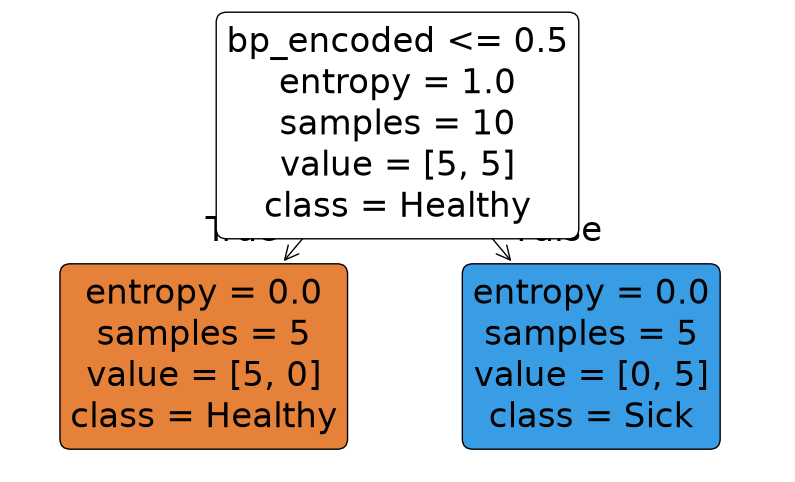

In [74]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["Healthy", "Sick"],
    filled=True,
    rounded=True
)

plt.show()

In [75]:
new_patient = pd.DataFrame(
    [[50, 0, 0]],
    columns=[
        "age",
        "bp_encoded",
        "cholesterol_encoded"
    ]
)

prediction = model.predict(new_patient)

if prediction[0] == 0:
    diagnosis = "Healthy"

else:
    diagnosis = "Sick"

print(f"Predicted diagnosis: {diagnosis}")

Predicted diagnosis: Healthy


## Additional questions

#### 1. We have data from the questionnaires survey (to ask people opinion) and objective testing with two attributes (acid durability and strength) to classify whether a special paper tissue is good or not. Here is four training samples as follows. Apply the K-nearest neighbour’s (KNN) algorithm when K=2, 3 and 4 to classify an instance (3, 7) as good or bad. Implement the above using python code without using scikit learn library. Plot the given samples Bad in Red color and Good in green color. Also draw the decision boundary. Calculate the desistance using Euclidean, Manhattan, and  Minkowski and compare. 

In [76]:
data = {
    "x1": [7, 7, 3, 1, 4, 3, 4, 8, 7, 8],
    "x2": [7, 4, 4, 4, 5, 5, 6, 7, 9, 8],
    "class": [
        "Bad", "Bad", "Good", "Good", "Bad",
        "Good", "Bad", "Bad", "Good", "Bad"
    ]
}

df = pd.DataFrame(data)
df.to_csv("acid.csv", index=False)

In [77]:
df = pd.read_csv("acid.csv")
df.head()

,x1,x2,class
0,7,7,Bad
1,7,4,Bad
2,3,4,Good
3,1,4,Good
4,4,5,Bad


In [78]:
new_point = np.array([3, 7])

In [79]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))


def minkowski_distance(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [80]:
euclidean = []
manhattan = []
minkowski = []

for i in range(len(df)):
    point = np.array([
        df.loc[i, "x1"],
        df.loc[i, "x2"]
    ])

    euclidean.append(
        euclidean_distance(new_point, point)
    )

    manhattan.append(
        manhattan_distance(new_point, point)
    )

    minkowski.append(
        minkowski_distance(new_point, point, p=3)
    )

df["euclidean"] = euclidean
df["manhattan"] = manhattan
df["minkowski"] = minkowski

df.head()

,x1,x2,class,euclidean,manhattan,minkowski
0,7,7,Bad,4.000000,4,4.000000
1,7,4,Bad,5.000000,7,4.497941
2,3,4,Good,3.000000,3,3.000000
3,1,4,Good,3.605551,5,3.271066
4,4,5,Bad,2.236068,3,2.080084


In [81]:
from collections import Counter

def knn_predict(df, new_point, k=3, metric="euclidean", p=3):
    neighbors = []

    for i in range(len(df)):
        point = np.array([
            df.loc[i, "x1"],
            df.loc[i, "x2"]
        ])

        if metric == "euclidean":
            distance = euclidean_distance(new_point, point)

        elif metric == "manhattan":
            distance = manhattan_distance(new_point, point)

        elif metric == "minkowski":
            distance = minkowski_distance(new_point, point, p=p)

        neighbors.append(
            (distance, df.loc[i, "class"])
        )

    neighbors.sort(key=lambda x: x[0])
    nearest_neighbors = neighbors[:k]
    labels = [label for distance, label in nearest_neighbors]
    counts = Counter(labels)

    if counts["Good"] > counts["Bad"]:
        prediction = "Good"

    elif counts["Bad"] > counts["Good"]:
        prediction = "Bad"

    else:
        prediction = nearest[0][1]

    return prediction, nearest_neighbors, counts

In [82]:
for k in [2, 3, 4]:
    prediction, nearest, counts = knn_predict(
        df,
        new_point,
        k=k
    )

    print(f"\nk = {k}")
    print("Nearest Neighbors:")

    for distance, label in nearest:
        print(
            f"Distance = {distance:.3f}, "
            f"Class = {label}"
        )

    print(f"Votes: {counts}")
    print(f"Prediction: {prediction}")

NameError: name 'nearest' is not defined

In [ ]:
for metric in [
    "euclidean",
    "manhattan",
    "minkowski"
]:
    prediction, nearest, _ = knn_predict(
        df,
        new_point,
        k=3,
        metric=metric,
        p=3
    )

    print(f"\n{metric.upper()}")

    for distance, label in nearest:
        print(
            f"Distance = {distance:.3f}, "
            f"Class: {label}"
        )

    print(f"Prediction: {prediction}")


EUCLIDEAN
Distance = 1.414, Class: Bad
Distance = 2.000, Class: Good
Distance = 2.236, Class: Bad
Prediction: Bad

MANHATTAN
Distance = 2.000, Class: Good
Distance = 2.000, Class: Bad
Distance = 3.000, Class: Good
Prediction: Good

MINKOWSKI
Distance = 1.260, Class: Bad
Distance = 2.000, Class: Good
Distance = 2.080, Class: Bad
Prediction: Bad


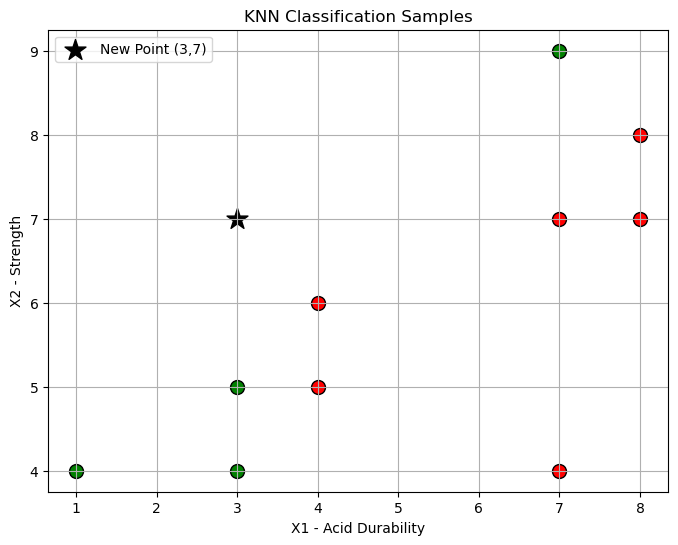

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(len(df)):
    if df.loc[i, "class"] == "Bad":
        plt.scatter(
            df.loc[i, "x1"],
            df.loc[i, "x2"],
            color="red",
            edgecolor="black",
            s=100
        )

    else:
        plt.scatter(
            df.loc[i, "x1"],
            df.loc[i, "x2"],
            color="green",
            edgecolor="black",
            s=100
        )

plt.scatter(
    new_point[0],
    new_point[1],
    color="black",
    marker="*",
    s=250,
    label="New Point (3,7)"
)

plt.xlabel("X1 - Acid Durability")
plt.ylabel("X2 - Strength")
plt.title("KNN Classification Samples")

plt.legend()
plt.grid()

plt.show()

In [ ]:
def plot_decision_boundary(df, k=3, metric="euclidean", p=3):
    x1_min = df["x1"].min() - 1
    x1_max = df["x1"].max() + 1

    x2_min = df["x2"].min() - 1
    x2_max = df["x2"].max() + 1

    x1_values = np.linspace(
        x1_min,
        x1_max,
        200
    )

    x2_values = np.linspace(
        x2_min,
        x2_max,
        200
    )

    xx, yy = np.meshgrid(
        x1_values,
        x2_values
    )

    Z = np.zeros(xx.shape)

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = np.array([
                xx[i, j],
                yy[i, j]
            ])

            prediction, _, _ = knn_predict(
                df,
                point,
                k=k,
                metric=metric,
                p=p
            )

            if prediction == "Good":
                Z[i, j] = 0

            else:
                Z[i, j] = 1

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        colors=["green", "red"],
        alpha=0.25
    )

    plt.contour(
        xx,
        yy,
        Z,
        levels=[0.5],
        colors="black"
    )

    for i in range(len(df)):
        if df.loc[i, "class"] == "Bad":
            plt.scatter(
                df.loc[i, "x1"],
                df.loc[i, "x2"],
                color="red",
                edgecolor="black",
                s=100
            )

        else:
            plt.scatter(
                df.loc[i, "x1"],
                df.loc[i, "x2"],
                color="green",
                edgecolor="black",
                s=100
            )

    plt.scatter(
        new_point[0],
        new_point[1],
        color="black",
        marker="*",
        s=250,
        label="New Point (3,7)"
    )

    plt.xlabel("X1 - Acid Durability")
    plt.ylabel("X2 - Strength")

    plt.title(f"KNN Decision Boundary - {metric.capitalize()} - k={k}")

    plt.legend()
    plt.grid()

    plt.show()

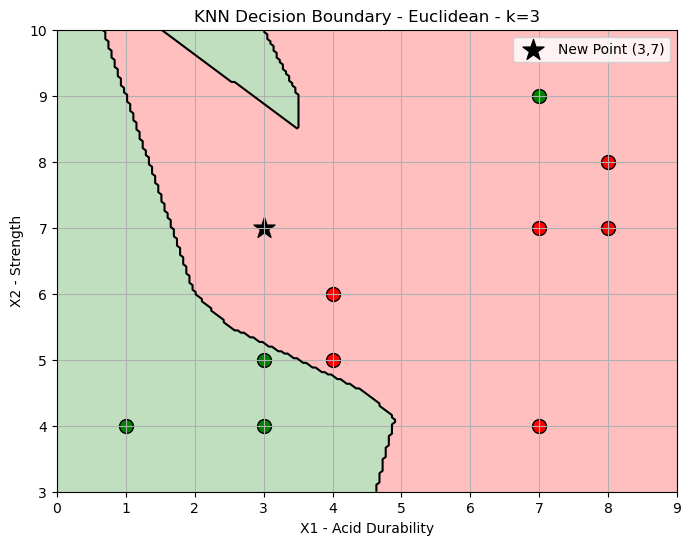

In [ ]:
plot_decision_boundary(
    df,
    k=3,
    metric="euclidean"
)

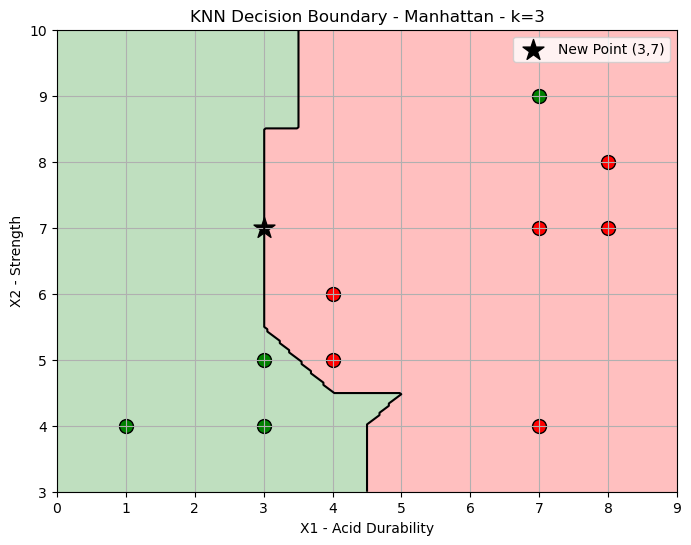

In [ ]:
plot_decision_boundary(
    df,
    k=3,
    metric="manhattan"
)

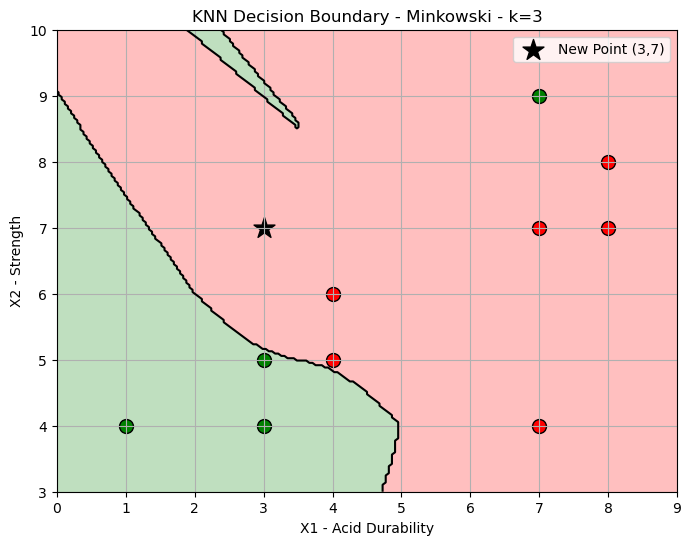

In [ ]:
plot_decision_boundary(
    df,
    k=3,
    metric="minkowski",
    p=3
)

#### 2. Implement Question 1 with using ```scikit-learn``` library. Plot the given samples Bad in Red color and Good in green color. Also plot the decision boundary. Calculate the distance using Euclidean, Manhattan, and Minkowski and compare the results.

In [ ]:
df = pd.read_csv("acid.csv")
df.head()

,x1,x2,class
0,7,7,Bad
1,7,4,Bad
2,3,4,Good
3,1,4,Good
4,4,5,Bad


In [ ]:
X = df[["x1", "x2"]].values
y = df["class"].values

new_point = np.array([[3, 7]])

In [ ]:
knn_euclidean = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn_euclidean.fit(X, y)
prediction_euclidean = knn_euclidean.predict(new_point)

print(f"Euclidean Prediction: {prediction_euclidean[0]}")

Euclidean Prediction: Bad


In [ ]:
knn_manhattan = KNeighborsClassifier(
    n_neighbors=3,
    metric="manhattan"
)

knn_manhattan.fit(X, y)
prediction_manhattan = knn_manhattan.predict(new_point)

print(f"Manhattan Prediction: {prediction_manhattan[0]}")

Manhattan Prediction: Good


In [ ]:
knn_minkowski = KNeighborsClassifier(
    n_neighbors=3,
    metric="minkowski",
    p=3
)

knn_minkowski.fit(X, y)
prediction_minkowski = knn_minkowski.predict(new_point)

print(f"Minkowski Prediction: {prediction_minkowski[0]}")

Minkowski Prediction: Bad


In [ ]:
models = {
    "euclidean": knn_euclidean,
    "manhattan": knn_manhattan,
    "minkowski": knn_minkowski
}

for name, model in models.items():
    distances, indices = model.kneighbors(
        new_point,
        n_neighbors=3
    )

    prediction = model.predict(new_point)[0]

    print(f"\n{name.upper()}")
    print("3 Nearest Neighbours:")

    for distance, index in zip(
        distances[0],
        indices[0]
    ):

        print(
            f"Point = ({X[index][0]}, {X[index][1]}), "
            f"Class = {y[index]}, "
            f"Distance = {distance:.3f}"
        )

    print(f"Prediction: {prediction}")


EUCLIDEAN
3 Nearest Neighbours:
Point = (4, 6), Class = Bad, Distance = 1.414
Point = (3, 5), Class = Good, Distance = 2.000
Point = (4, 5), Class = Bad, Distance = 2.236
Prediction: Bad

MANHATTAN
3 Nearest Neighbours:
Point = (3, 5), Class = Good, Distance = 2.000
Point = (4, 6), Class = Bad, Distance = 2.000
Point = (3, 4), Class = Good, Distance = 3.000
Prediction: Good

MINKOWSKI
3 Nearest Neighbours:
Point = (4, 6), Class = Bad, Distance = 1.260
Point = (3, 5), Class = Good, Distance = 2.000
Point = (4, 5), Class = Bad, Distance = 2.080
Prediction: Bad


In [ ]:
for k in [2, 3, 4]:
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    model.fit(X, y)
    prediction = model.predict(new_point)[0]

    print(f"k = {k} -> Prediction = {prediction}")

k = 2 -> Prediction = Bad
k = 3 -> Prediction = Bad
k = 4 -> Prediction = Bad


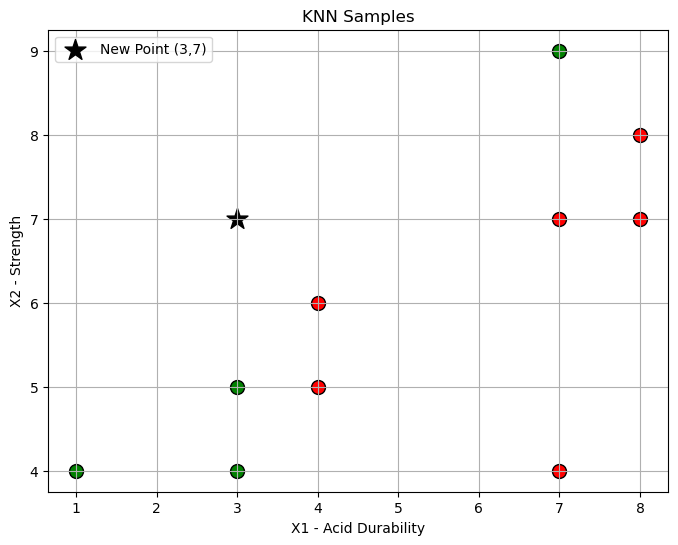

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(len(X)):
    if y[i] == "Bad":
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color="red",
            edgecolor="black",
            s=100
        )

    else:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color="green",
            edgecolor="black",
            s=100
        )

plt.scatter(
    new_point[0, 0],
    new_point[0, 1],
    color="black",
    marker="*",
    s=250,
    label="New Point (3,7)"
)

plt.xlabel("X1 - Acid Durability")
plt.ylabel("X2 - Strength")
plt.title("KNN Samples")

plt.legend()
plt.grid()
plt.show()

In [ ]:
def plot_boundary(model, title):
    x1_min = X[:, 0].min() - 1
    x1_max = X[:, 0].max() + 1

    x2_min = X[:, 1].min() - 1
    x2_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(grid)

    Z = np.where(
        predictions == "Good",
        0,
        1
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        colors=["green", "red"],
        alpha=0.25
    )

    plt.contour(
        xx,
        yy,
        Z,
        levels=[0.5],
        colors="black"
    )

    for i in range(len(X)):
        if y[i] == "Bad":
            plt.scatter(
                X[i, 0],
                X[i, 1],
                color="red",
                edgecolor="black",
                s=100
            )

        else:
            plt.scatter(
                X[i, 0],
                X[i, 1],
                color="green",
                edgecolor="black",
                s=100
            )

    plt.scatter(
        new_point[0, 0],
        new_point[0, 1],
        color="black",
        marker="*",
        s=250,
        label="New Point (3,7)"
    )

    plt.xlabel("X1 - Acid Durability")
    plt.ylabel("X2 - Strength")
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()

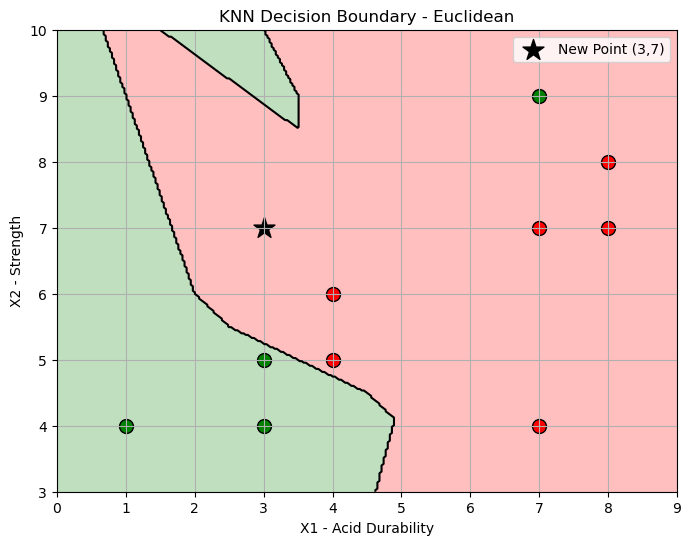

In [ ]:
plot_boundary(
    knn_euclidean,
    "KNN Decision Boundary - Euclidean"
)

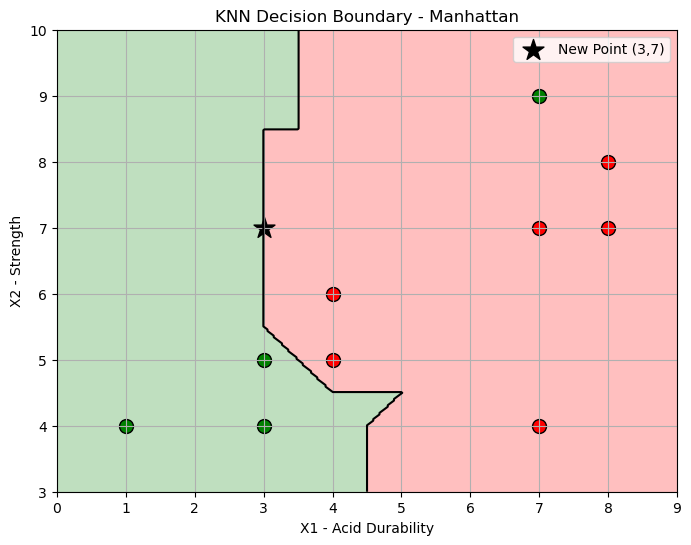

In [ ]:
plot_boundary(
    knn_manhattan,
    "KNN Decision Boundary - Manhattan"
)

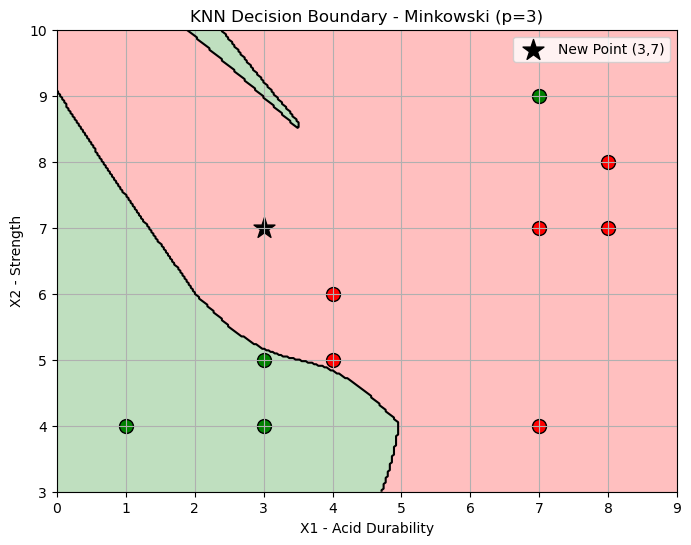

In [ ]:
plot_boundary(
    knn_minkowski,
    "KNN Decision Boundary - Minkowski (p=3)"
)

#### 3. There is a Car manufacturer company that has manufactured a new SUV car. The company wants to give the ads to the users who are interested in buying that SUV. So for this problem, we have a dataset that contains multiple users' information through the social network. The dataset contains lots of information but the Estimated Salary and Age we will consider for the independent variable and the Purchased variable is for the dependent variable. Below is the dataset: 
- Apply the K-NN algorithm when K=2, 3 and 4 to classify purchased or not. Calculate the distance using Euclidean, Manhattan, and Minkowski and compare.
- Test your developed K-NN without and with using Scikit Learn Library.
- Plot the Yellow points are for Purchased(1) and Green Points for not Purchased(0) variable.
- Show the graph has to classify users in the correct categories, as most of the users who didn't buy the SUV are in the red region, and users who bought the SUV are in the green region.

In [83]:
data = {
    "Age": [
        19, 35, 26, 27, 19, 27, 27, 32, 25, 35, 26,
        26, 20, 32, 18, 29, 47, 45, 46, 48, 45, 47
    ],

    "EstimatedSalary": [
        19000, 20000, 43000, 57000, 76000, 58000,
        84000, 150000, 33000, 65000, 80000, 52000,
        86000, 18000, 82000, 80000, 25000, 26000,
        28000, 29000, 22000, 49000
    ],

    "Purchased": [
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
df.to_csv("car_users.csv", index=False)

In [84]:
df = pd.read_csv("car_users.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [85]:
X = df[["Age", "EstimatedSalary"]].values.astype(float)
y = df["Purchased"].values

In [86]:
np.random.seed(67)

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.7 * len(X))

train_indices = indices[:split]
test_indices = indices[split:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

In [87]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Mean: [3.20e+01 4.26e+04]
Standard deviation: [1.10513951e+01 2.47811757e+04]


In [88]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))


def minkowski_distance(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [89]:
def knn_predict(X_train, y_train, point, k=3, metric="euclidean", p=3):
    distances = []

    for i in range(len(X_train)):
        if metric == "euclidean":
            distance = euclidean_distance(
                point,
                X_train[i]
            )

        elif metric == "manhattan":
            distance = manhattan_distance(
                point,
                X_train[i]
            )

        elif metric == "minkowski":
            distance = minkowski_distance(
                point,
                X_train[i],
                p
            )

        distances.append(
            (distance, y_train[i])
        )

    distances.sort(key=lambda x: x[0])
    nearest = distances[:k]

    labels = [
        label for distance, label in nearest
    ]

    counts = Counter(labels)

    max_votes = max(counts.values())

    tied_classes = [
        c for c, count in counts.items()
        if count == max_votes
    ]

    prediction = min(tied_classes)

    return prediction

In [90]:
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [91]:
manual_results = []

for metric in [
    "euclidean",
    "manhattan",
    "minkowski"
]:

    for k in [2, 3, 4]:
        predictions = []

        for point in X_test_scaled:
            pred = knn_predict(
                X_train_scaled,
                y_train,
                point,
                k=k,
                metric=metric,
                p=3
            )

            predictions.append(pred)

        predictions = np.array(predictions)

        accuracy = calculate_accuracy(
            y_test,
            predictions
        )

        manual_results.append([
            metric,
            k,
            accuracy
        ])

manual_results_df = pd.DataFrame(
    manual_results,
    columns=[
        "Distance",
        "K",
        "Accuracy"
    ]
)

manual_results_df.head()

,Distance,K,Accuracy
0,euclidean,2,0.857143
1,euclidean,3,0.857143
2,euclidean,4,0.857143
3,manhattan,2,0.857143
4,manhattan,3,0.857143


In [92]:
df = pd.read_csv("car_users.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [93]:
X = df[["Age", "EstimatedSalary"]].values
y = df["Purchased"].values

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=67
)

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.55423789,  0.65549954],
       [-1.51349579,  0.83319519],
       [ 1.4708621 , -0.85491355],
       [-0.98057473, -0.73644978],
       [ 1.25769368, -0.8845295 ]])

In [96]:
from sklearn.metrics import accuracy_score

sklearn_results = []

for metric in ["euclidean", "manhattan", "minkowski"]:
    for k in [2, 3, 4]:
        if metric == "minkowski":
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric="minkowski",
                p=3
            )

        else:
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric
            )

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        sklearn_results.append([
            metric,
            k,
            accuracy
        ])

sklearn_results_df = pd.DataFrame(
    sklearn_results,
    columns=[
        "Metric",
        "K",
        "Sklearn Accuracy"
    ]
)

sklearn_results_df.head()

,Metric,K,Sklearn Accuracy
0,euclidean,2,1.0
1,euclidean,3,1.0
2,euclidean,4,1.0
3,manhattan,2,1.0
4,manhattan,3,1.0


In [97]:
for metric in ["euclidean", "manhattan", "minkowski"]:
    for k in [2, 3, 4]:
        if metric == "minkowski":
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric="minkowski",
                p=3
            )

        else:
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric
            )

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        print(
            f"{metric.upper()} | K = {k}"
        )

        print(f"Actual {y_test}: ")
        print(f"Predicted: {y_pred}")

        print(
            "fAccuracy: {accuracy_score(y_test, y_pred)}"
        )

        print()

EUCLIDEAN | K = 2
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

EUCLIDEAN | K = 3
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

EUCLIDEAN | K = 4
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MANHATTAN | K = 2
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MANHATTAN | K = 3
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MANHATTAN | K = 4
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MINKOWSKI | K = 2
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MINKOWSKI | K = 3
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: {accuracy_score(y_test, y_pred)}

MINKOWSKI | K = 4
Actual [0 0 1 0 0 0 0]: 
Predicted: [0 0 1 0 0 0 0]
fAccuracy: